# Reach-scale confinement: a quick aggregation sensitivity check

Aggregate the existing bend measurements by **`file` + `combined_reach_id`** (IDs can repeat between files). This summarizes the bend method at reach scale; it does not recompute confinement from reach geometry.

Start with continuous patterns, without reclustering. We compare distributions, width/elevation relationships, and within-reach variability. Keep the same source, height factor and bend normalization as `final_results.ipynb`. Normalize each bend **before** aggregation; averaging ratios is a different quantity from taking a ratio of reach averages.

The default is a bend-length-weighted arithmetic mean, with equal-bend means as a sensitivity check. Inner/outer remain bend-relative; left/right must retain the pipeline's orientation convention. An average can hide alternating confined and unconfined sections.

**Corrected population:** the main slope analysis requires raw slope coverage only. Missing confinement ratios or smoothed slopes do not exclude a reach. Earlier ratio-filtered results are historical and are compared explicitly at the end.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / 'pipeline' / 'paths.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from pipeline.paths import load_project_paths, format_factor_token

CONFIG = None  # uses RIVER_CONFINEMENT_PATHS / paths.local.json if configured
HEIGHT_FACTOR = 2
paths = load_project_paths(CONFIG)
# Same manuscript archive as final_results.ipynb; set None for canonical results.
INPUT_OVERRIDE = Path('/Volumes/PhD/confinement/results/single_values/global_50_02_smoothed.nc')
source = INPUT_OVERRIDE if INPUT_OVERRIDE is not None else (
    paths.single_smoothed_dir / f'global_50_{format_factor_token(HEIGHT_FACTOR)}_smoothed.nc')
OUT = ROOT / 'results' / 'reach_scale_check'
OUT.mkdir(parents=True, exist_ok=True)
KEY = ['file', 'combined_reach_id']
SIDES = ['out', 'right', 'left', 'inn']
SLOPES = [f'slope_{s}_normalized' for s in SIDES]
FEATURES = SLOPES + [f'{c}_smooth' for c in SLOPES]  # existing PCA inputs
METRICS = FEATURES + ['ER_out', 'ER_inn', 'bendWidths', 'bendHeight']
MIN_COVERAGE = 0.8  # analyst choice: fraction of known positive bend length
print('Input:', source)


Input: /Volumes/PhD/confinement/results/single_values/global_50_02_smoothed.nc


In [2]:
required = KEY + ['bendID', 'bendLen', 'cm_height', 'cp_height', 'bendWidths',
                  'bendHeight', 'ER_out', 'ER_inn'] + [f'slope_{s}' for s in SIDES]
required += [f'{c}_smooth' for c in SLOPES]
with xr.open_dataset(source) as ds:
    missing = sorted(set(required) - set(ds.variables))
    if missing:
        raise ValueError(f'Missing input columns: {missing}')
    bends = ds[list(dict.fromkeys(required))].to_dataframe().reset_index(drop=True)
if bends[KEY + ['bendID']].isna().any().any():
    raise ValueError('Missing reach/bend identifiers; repair these before grouping.')
if bends.duplicated(KEY + ['bendID']).any():
    raise ValueError('Duplicate bend identifiers within a source reach.')

# Exactly the raw-slope normalization used in final_results.ipynb.
maximum = (bends.cm_height - bends.cp_height) / (bends.bendWidths * 0.5)
maximum = maximum.where((maximum > 0) & (bends.bendWidths > 0))
for side in SIDES:
    bends[f'slope_{side}_normalized'] = bends[f'slope_{side}'] / maximum
bends[METRICS + ['bendLen']] = bends[METRICS + ['bendLen']].replace([np.inf, -np.inf], np.nan)
bends['outer_minus_inner'] = bends.slope_out_normalized - bends.slope_inn_normalized
METRICS += ['outer_minus_inner']
print(f'{len(bends):,} bends; {len(bends.groupby(KEY)):,} source reaches')


1,490,573 bends; 140,471 source reaches


## Aggregate and retain coverage

For each metric, divide the sum of valid `bendLen × value` by valid bend length. Missing values never become zeros. Report valid counts, length coverage, weighted standard deviation and equal-bend means. Reaches with any unknown/nonpositive bend length are excluded from the main comparison because their length coverage cannot be established. Coverage refers to input bends, **not** verified coverage of the complete mapped reach.

The main reach filter requires ≥80% coverage for each of the four raw normalized slopes. Ratios have a separate cohort. Smoothed slopes are retained as optional features without controlling selection. Predictor availability is checked separately for width/elevation comparisons.

In [3]:
def aggregate_reaches(frame, metrics):
    frame = frame.copy()
    good_length = frame.bendLen.notna() & (frame.bendLen > 0)
    frame['_weight'] = frame.bendLen.where(good_length, 0.0)
    frame['_bad_length'] = ~good_length
    grouped = frame.groupby(KEY, sort=True)
    reach = grouped.agg(n_bends=('bendLen', 'size'),
                        bad_length_bends=('_bad_length', 'sum'),
                        known_bend_length=('_weight', 'sum'))
    for metric in metrics:
        valid = frame[metric].notna() & good_length
        weights = frame['_weight'].where(valid, 0.0)
        values = frame[metric].where(valid, 0.0)
        work = frame[KEY].assign(w=weights, wx=weights * values)
        sums = work.groupby(KEY).sum()
        denominator = sums.w.replace(0, np.nan)
        reach[metric] = sums.wx / denominator
        # Centered variance avoids cancellation in nearly constant reaches.
        means = frame[KEY].join(reach[metric], on=KEY)[metric]
        work['wdev2'] = weights * (values - means).pow(2)
        reach[metric + '_std'] = np.sqrt(work.groupby(KEY).wdev2.sum() / denominator)
        reach[metric + '_coverage'] = sums.w / reach.known_bend_length.replace(0, np.nan)
        reach[metric + '_n'] = frame.assign(_valid=valid).groupby(KEY)._valid.sum()
        reach[metric + '_equal_bend'] = frame[metric].where(valid).groupby(
            [frame[k] for k in KEY]).mean()
    return reach

reach_all = aggregate_reaches(bends, METRICS)
# Select on raw slopes only: ratio and smoothing availability are not slope criteria.
def coverage_mask(table, metrics):
    return ((table.bad_length_bends == 0)
            & table[[c + '_coverage' for c in metrics]].ge(MIN_COVERAGE).all(axis=1)
            & table[metrics].notna().all(axis=1))

keep = coverage_mask(reach_all, SLOPES)
legacy_keep = coverage_mask(reach_all, METRICS)
reach = reach_all.loc[keep].copy()
if reach.empty:
    raise ValueError('No reaches pass raw slope coverage.')
b = bends.join(reach[['n_bends']], on=KEY, how='inner')
# Complete raw slopes only; absent ER or smoothed values must not remove bends.
b = b.dropna(subset=SLOPES).copy()
coverage_audit = pd.DataFrame([
    {'population': 'all_input', 'reaches': len(reach_all)},
    {'population': 'raw_slopes_main', 'reaches': int(keep.sum())},
    {'population': 'raw_and_smoothed_slopes',
     'reaches': int(coverage_mask(reach_all, FEATURES).sum())},
    {'population': 'ratios_only_separate',
     'reaches': int(coverage_mask(reach_all, ['ER_out', 'ER_inn']).sum())},
    {'population': 'original_combined_filter', 'reaches': int(legacy_keep.sum())},
    {'population': 'newly_included_raw_slope_reaches', 'reaches': int((keep & ~legacy_keep).sum())},
])
display(coverage_audit)
coverage_audit.to_csv(OUT / 'coverage_audit.csv', index=False)
# Ratios are exported for their own cohort; they never gate the slope analysis.
ratio_reach = reach_all.loc[coverage_mask(reach_all, ['ER_out', 'ER_inn'])]
ratio_reach.reset_index().to_parquet(OUT / 'reach_metrics_ratio_cohort.parquet', index=False)
print(f'Retained {len(reach):,}/{len(reach_all):,} reaches; '
      f'{len(b):,} complete raw-slope bends in retained reaches.')
display(reach[['n_bends', 'known_bend_length']].describe())
reach_all.reset_index().to_parquet(OUT / 'reach_metrics_all.parquet', index=False)
reach.reset_index().to_parquet(OUT / 'reach_metrics_retained.parquet', index=False)


Retained 140,176/140,471 reaches; 1,487,493 complete raw-slope bends in retained reaches.


,population,reaches
0,all_input,140471
1,raw_slopes_main,140176
2,raw_and_smoothed_slopes,140091
3,ratios_only_separate,96202
4,original_combined_filter,96167
5,newly_included_raw_slope_reaches,44009


,n_bends,known_bend_length
count,140176.000000,140176.000000
mean,10.612180,14001.260885
std,6.817417,11078.453150
min,1.000000,204.713647
25%,6.000000,9942.107965
50%,9.000000,11163.184649
75%,14.000000,17170.047626
max,82.000000,458082.968071


## Do distributions and relationships change?

The equal-bend and equal-reach comparisons also change the sampling weight. The length-weighted bend/reach curves help separate this effect from averaging. Spearman correlations below are descriptive, not independent-sample significance tests; nearby bends/reaches share spatial structure. Inspect effect sizes and common-bin trends rather than interpreting a large sample's p-value as robustness.

cell-6:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,metric,bend_median,reach_median,bend_IQR,reach_IQR,median_within_reach_std,median_abs_weighting_difference
0,slope_out_normalized,0.118402,0.260883,0.431844,0.417171,0.202161,0.018148
1,slope_inn_normalized,0.062581,0.128875,0.236189,0.319291,0.101681,0.010007
2,outer_minus_inner,0.009904,0.048522,0.197328,0.169490,0.252657,0.023494


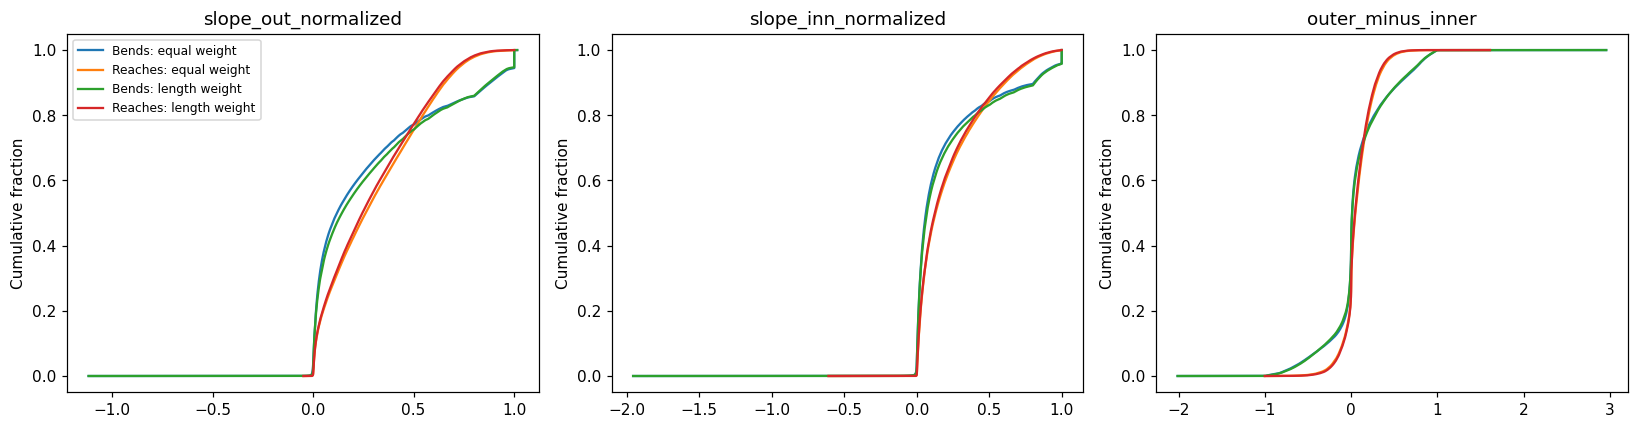

In [4]:
CHECK = ['slope_out_normalized', 'slope_inn_normalized', 'outer_minus_inner']
summary = []
for c in CHECK:
    summary.append({'metric': c, 'bend_median': b[c].median(),
                    'reach_median': reach[c].median(),
                    'bend_IQR': b[c].quantile(.75) - b[c].quantile(.25),
                    'reach_IQR': reach[c].quantile(.75) - reach[c].quantile(.25),
                    'median_within_reach_std': reach[c + '_std'].median(),
                    'median_abs_weighting_difference':
                        (reach[c] - reach[c + '_equal_bend']).abs().median()})
summary = pd.DataFrame(summary)
display(summary)
summary.to_csv(OUT / 'distribution_summary.csv', index=False)

def ecdf(ax, values, weights, label):
    order = np.argsort(np.asarray(values))
    x = np.asarray(values)[order]
    w = np.asarray(weights)[order]
    y = np.cumsum(w) / w.sum()
    # Keep plots compact without changing calculations.
    select = np.unique(np.linspace(0, len(x) - 1, min(len(x), 5000)).astype(int))
    ax.plot(x[select], y[select], label=label)

fig, axes = plt.subplots(1, len(CHECK), figsize=(15, 4))
for ax, c in zip(axes, CHECK):
    ecdf(ax, b[c], np.ones(len(b)), 'Bends: equal weight')
    ecdf(ax, reach[c], np.ones(len(reach)), 'Reaches: equal weight')
    ecdf(ax, b[c], b.bendLen, 'Bends: length weight')
    ecdf(ax, reach[c], reach.known_bend_length, 'Reaches: length weight')
    ax.set(title=c, ylabel='Cumulative fraction')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'distributions.png', dpi=160)
plt.show()


cell-7:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,predictor,metric,rho_bend,rho_reach,delta_rho,n_bends,n_reaches
0,bendWidths,slope_out_normalized,0.131654,0.039011,-0.092643,1487493,140176
1,bendWidths,slope_inn_normalized,0.155228,0.091998,-0.063230,1487493,140176
2,bendWidths,outer_minus_inner,0.000070,-0.107488,-0.107557,1487493,140176
3,bendHeight,slope_out_normalized,0.264430,0.324248,0.059818,1487493,140176
4,bendHeight,slope_inn_normalized,0.241414,0.274395,0.032981,1487493,140176
5,bendHeight,outer_minus_inner,0.083468,0.166972,0.083504,1487493,140176


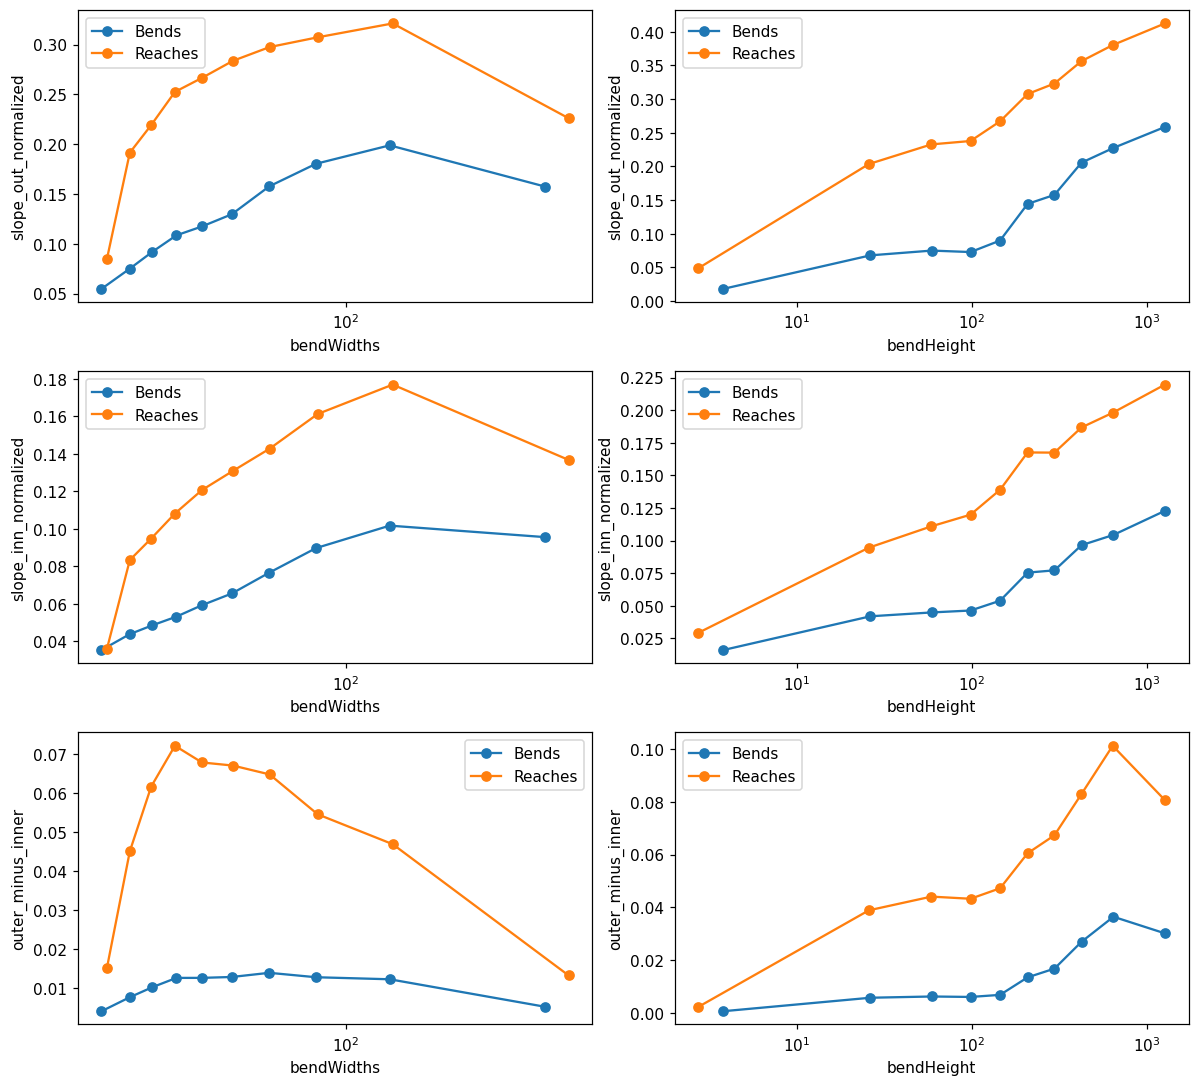

In [5]:
relationships = []
fig, axes = plt.subplots(len(CHECK), 2, figsize=(11, 10), squeeze=False)
for j, predictor in enumerate(['bendWidths', 'bendHeight']):
    predictor_reach = reach.loc[reach[predictor + '_coverage'].ge(MIN_COVERAGE)
                                & reach[predictor].notna()]
    predictor_bends = b.merge(predictor_reach.reset_index()[KEY], on=KEY, how='inner')
    predictor_bends = predictor_bends.dropna(subset=[predictor])
    # Shared bin boundaries at both scales, from bend quantiles.
    edges = np.unique(predictor_bends[predictor].quantile(np.linspace(0, 1, 11)).to_numpy())
    if len(edges) < 3:
        print('Too few unique values for binned trends:', predictor)
        continue
    edges[0], edges[-1] = -np.inf, np.inf
    for i, c in enumerate(CHECK):
        rb = predictor_bends[[predictor, c]].corr(method='spearman').iloc[0, 1]
        rr = predictor_reach[[predictor, c]].corr(method='spearman').iloc[0, 1]
        relationships.append({'predictor': predictor, 'metric': c,
                              'rho_bend': rb, 'rho_reach': rr, 'delta_rho': rr - rb,
                              'n_bends': len(predictor_bends), 'n_reaches': len(predictor_reach)})
        for frame, label in [(predictor_bends, 'Bends'), (predictor_reach, 'Reaches')]:
            bins = pd.cut(frame[predictor], edges, include_lowest=True)
            trend = frame.groupby(bins, observed=True).agg(
                x=(predictor, 'median'), y=(c, 'median'), n=(c, 'count'))
            trend = trend[trend.n >= 10]
            axes[i, j].plot(trend.x, trend.y, 'o-', label=label)
        axes[i, j].set(xlabel=predictor, ylabel=c)
        axes[i, j].set_xscale('symlog', linthresh=1)
        axes[i, j].legend()
fig.tight_layout()
fig.savefig(OUT / 'width_elevation_trends.png', dpi=160)
plt.show()
relationships = pd.DataFrame(relationships)
display(relationships)
relationships.to_csv(OUT / 'relationships.csv', index=False)


## Does an intermediate reach mean hide extreme bend values?

Use the **bend-length-weighted population STD** already calculated above:

$$\mu_r = \frac{\sum_i L_i x_i}{\sum_i L_i},\qquad
\sigma_r = \sqrt{\frac{\sum_i L_i(x_i-\mu_r)^2}{\sum_i L_i}}.$$

This describes variation among observed bends, not uncertainty in the mean. A reach with one valid bend has STD = 0 but provides no evidence of within-reach uniformity; the diagnostic below requires at least two valid bends.

For the raw inner and outer normalized slopes, also calculate the fraction of **valid observed bend length** below a low threshold and above a high threshold. Use the same metric-specific valid bends as each reach mean/STD, rather than the complete-case `b` table. Missing length fractions remain visible in the coverage column.

**Exploratory defaults:** low ≤ 0.2, high ≥ 0.8; an intermediate mean lies strictly between those thresholds. Flag contrasting extremes only when **each tail contains at least 10%** of valid bend length. These are adjustable diagnostic choices, not established confined/unconfined classes. Check threshold sensitivity before using the percentages in a manuscript. No values are clipped to [0, 1].

In [6]:
EXTREME_METRICS = ['slope_out_normalized', 'slope_inn_normalized']
LOW_THRESHOLD = 0.2
HIGH_THRESHOLD = 0.8
MIN_TAIL_FRACTION = 0.10
MIN_VALID_BENDS = 2
assert LOW_THRESHOLD < HIGH_THRESHOLD
assert 0 < MIN_TAIL_FRACTION <= 0.5
assert MIN_VALID_BENDS >= 2


def within_reach_extremes(frame, retained, metric, low, high, tail_fraction, min_bends):
    # retained identifies the existing coverage-filtered reach cohort.
    selected = frame.join(retained[['known_bend_length']], on=KEY, how='inner')
    valid = selected.loc[np.isfinite(selected[metric])
                         & np.isfinite(selected.bendLen) & (selected.bendLen > 0)].copy()
    valid['low_length'] = valid.bendLen.where(valid[metric] <= low, 0.0)
    valid['high_length'] = valid.bendLen.where(valid[metric] >= high, 0.0)
    tails = valid.groupby(KEY).agg(valid_length=('bendLen', 'sum'),
                                  valid_bends=('bendLen', 'size'),
                                  low_length=('low_length', 'sum'),
                                  high_length=('high_length', 'sum'))
    result = retained[[metric, metric + '_std', 'known_bend_length']].rename(
        columns={metric: 'reach_mean', metric + '_std': 'within_reach_std'}).join(tails)
    result['coverage'] = result.valid_length / result.known_bend_length
    result['low_fraction'] = result.low_length / result.valid_length
    result['high_fraction'] = result.high_length / result.valid_length
    result['extreme_fraction'] = result.low_fraction + result.high_fraction
    result['smaller_tail_fraction'] = result[['low_fraction', 'high_fraction']].min(axis=1)
    result['eligible'] = result.valid_bends.ge(min_bends) & result.coverage.ge(MIN_COVERAGE)
    result['intermediate_mean'] = result.reach_mean.gt(low) & result.reach_mean.lt(high)
    result['both_tails'] = result.low_fraction.ge(tail_fraction) & result.high_fraction.ge(tail_fraction)
    result['hidden_extremes'] = result.eligible & result.intermediate_mean & result.both_tails
    result['metric'] = metric
    result['low_threshold'] = low
    result['high_threshold'] = high
    result['minimum_tail_fraction'] = tail_fraction
    result['minimum_valid_bends'] = min_bends
    return result

variability = pd.concat([
    within_reach_extremes(bends, reach, metric, LOW_THRESHOLD, HIGH_THRESHOLD,
                         MIN_TAIL_FRACTION, MIN_VALID_BENDS).reset_index()
    for metric in EXTREME_METRICS
], ignore_index=True)
variability.to_parquet(OUT / 'within_reach_variability.parquet', index=False)

variability_rows = []
for metric, data in variability.groupby('metric', sort=False):
    eligible = data.loc[data.eligible]
    intermediate = eligible.loc[eligible.intermediate_mean]
    variability_rows.append({
        'metric': metric,
        'eligible_reaches': len(eligible),
        'excluded_reaches': len(data) - len(eligible),
        'intermediate_reaches': len(intermediate),
        'intermediate_with_both_tails': int(intermediate.both_tails.sum()),
        'percent_intermediate_with_both_tails':
            100 * intermediate.both_tails.mean() if len(intermediate) else np.nan,
        'median_std_eligible': eligible.within_reach_std.median(),
        'median_std_intermediate': intermediate.within_reach_std.median(),
        'median_extreme_fraction_intermediate': intermediate.extreme_fraction.median(),
    })
variability_summary = pd.DataFrame(variability_rows)
display(variability_summary.round(3))
variability_summary.to_csv(OUT / 'within_reach_variability_summary.csv', index=False)


,metric,eligible_reaches,excluded_reaches,intermediate_reaches,intermediate_with_both_tails,percent_intermediate_with_both_tails,median_std_eligible,median_std_intermediate,median_extreme_fraction_intermediate
0,slope_out_normalized,135861,4315,76724,36449,47.507,0.209,0.278,0.531
1,slope_inn_normalized,135861,4315,50715,25952,51.172,0.111,0.281,0.583


cell-10:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


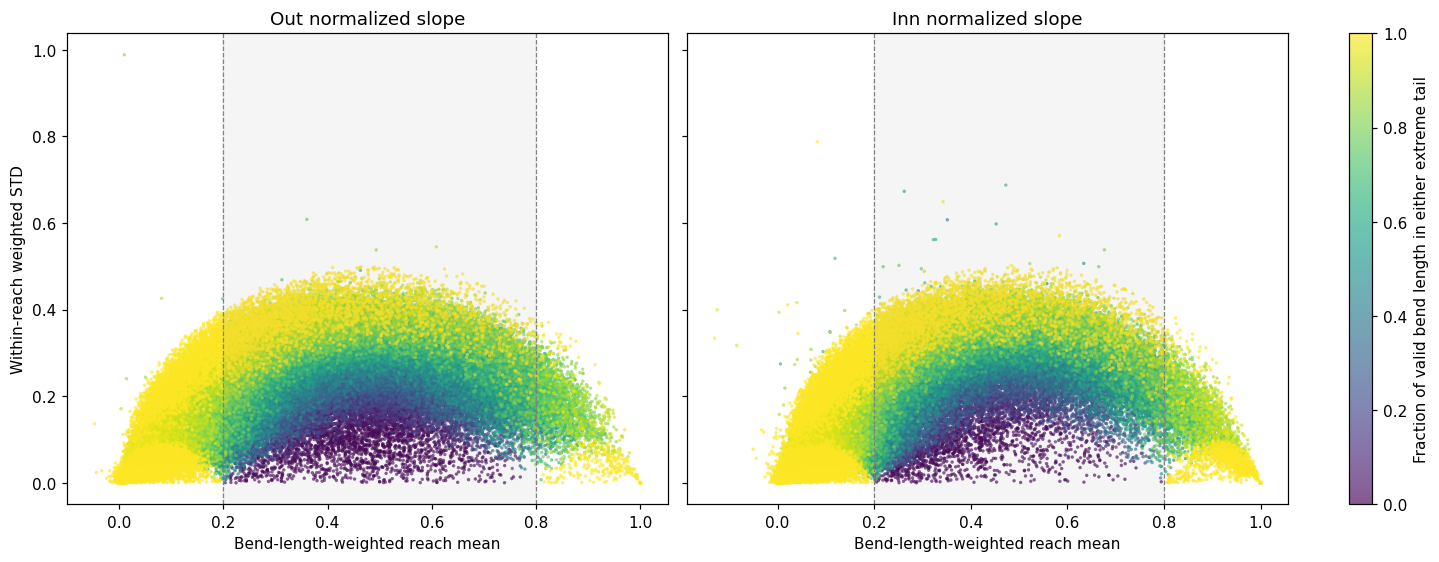

In [7]:
fig, axes = plt.subplots(1, len(EXTREME_METRICS), figsize=(13, 5),
                         sharey=True, layout='constrained')
for ax, metric in zip(np.atleast_1d(axes), EXTREME_METRICS):
    data = variability.loc[(variability.metric == metric) & variability.eligible]
    # Sort so high extreme fractions remain visible; all eligible reaches are plotted.
    data = data.sort_values('extreme_fraction')
    points = ax.scatter(data.reach_mean, data.within_reach_std,
                        c=data.extreme_fraction, cmap='viridis', vmin=0, vmax=1,
                        s=5, alpha=0.65, linewidths=0, rasterized=True)
    ax.axvspan(LOW_THRESHOLD, HIGH_THRESHOLD, color='grey', alpha=0.08)
    ax.axvline(LOW_THRESHOLD, color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(HIGH_THRESHOLD, color='grey', linestyle='--', linewidth=0.8)
    ax.set(title=metric.replace('slope_', '').replace('_normalized', '').title() + ' normalized slope',
           xlabel='Bend-length-weighted reach mean')
axes[0].set_ylabel('Within-reach weighted STD')
fig.colorbar(points, ax=list(np.atleast_1d(axes)),
             label='Fraction of valid bend length in either extreme tail')
fig.savefig(OUT / 'reach_mean_vs_std.png', dpi=180)
plt.show()


### Reading the figure

- **Intermediate mean, low STD:** the observed bend values cluster near the reach average.
- **Intermediate mean, high STD:** the reach average hides substantial bend-to-bend variation.
- **High extreme fraction:** much of the valid observed length lies in one or both tails. Colour alone does **not** establish that both extremes occur; use `low_fraction`, `high_fraction` and the `hidden_extremes` flag for that claim.

STD depends partly on the mean and the metric's bounds, so the shape of this cloud is not itself evidence of separate regimes. The calculation shows co-occurrence within a reach, not the downstream ordering of those conditions. It also does not establish the ecological or geomorphic importance of the extremes. The output below states what the selected thresholds actually show, separately for each bend side.

In [8]:
from IPython.display import Markdown

interpretation = [
    '### Within-reach interpretation for this run',
    f'Exploratory thresholds: low ≤ {LOW_THRESHOLD:g}, high ≥ {HIGH_THRESHOLD:g}; '
    f'each tail must occupy at least {MIN_TAIL_FRACTION:.0%} of valid bend length. '
    f'At least {MIN_VALID_BENDS} valid bends and {MIN_COVERAGE:.0%} input length coverage are required.'
]
for row in variability_summary.itertuples(index=False):
    if row.intermediate_reaches == 0:
        interpretation.append(f'**{row.metric}:** no eligible intermediate-mean reaches; '
                              'the contrasting-extremes percentage is undefined.')
        continue
    interpretation.append(
        f'**{row.metric}:** among {row.intermediate_reaches:,} eligible reaches with an '
        f'intermediate mean, {row.intermediate_with_both_tails:,} '
        f'({row.percent_intermediate_with_both_tails:.1f}%) contain both low and high bend values '
        f'at the specified length fractions. Median within-reach STD among intermediate reaches '
        f'is {row.median_std_intermediate:.3f}. '
        f'{row.excluded_reaches:,} retained reaches are excluded from this diagnostic '
        f'for insufficient valid bends or coverage.'
    )
interpretation.append(
    'Where both tails are present, an intermediate reach average summarizes contrasting local '
    'conditions rather than uniformly intermediate bends. This quantifies information hidden by '
    'averaging under the stated thresholds; it does not establish distinct physical regimes or '
    'a physical loss of extreme conditions. Repeat with justified alternative thresholds and '
    'consider the input-coverage selection before generalizing.'
)
interpretation_text = '\n\n'.join(interpretation)
display(Markdown(interpretation_text))
(OUT / 'within_reach_interpretation.md').write_text(interpretation_text + '\n', encoding='utf-8')


### Within-reach interpretation for this run

Exploratory thresholds: low ≤ 0.2, high ≥ 0.8; each tail must occupy at least 10% of valid bend length. At least 2 valid bends and 80% input length coverage are required.

**slope_out_normalized:** among 76,724 eligible reaches with an intermediate mean, 36,449 (47.5%) contain both low and high bend values at the specified length fractions. Median within-reach STD among intermediate reaches is 0.278. 4,315 retained reaches are excluded from this diagnostic for insufficient valid bends or coverage.

**slope_inn_normalized:** among 50,715 eligible reaches with an intermediate mean, 25,952 (51.2%) contain both low and high bend values at the specified length fractions. Median within-reach STD among intermediate reaches is 0.281. 4,315 retained reaches are excluded from this diagnostic for insufficient valid bends or coverage.

Where both tails are present, an intermediate reach average summarizes contrasting local conditions rather than uniformly intermediate bends. This quantifies information hidden by averaging under the stated thresholds; it does not establish distinct physical regimes or a physical loss of extreme conditions. Repeat with justified alternative thresholds and consider the input-coverage selection before generalizing.

## Clustering: only if it answers the next question

**For the scale sensitivity check above, no new clustering is needed.** If the question concerns the existing classes, summarize their bend-length fractions within each reach first. A dominant class alone hides mixed reaches. The optional cell below accepts the already classified bend table; do not join by row order or average numeric class labels.

To classify reach-average profiles using the existing definition, retain the original fitted scaler, PCA and GMM, then call `transform`/`predict` on the aggregated features in their original order. Do not refit preprocessing during transfer ([scikit-learn guidance](https://scikit-learn.org/stable/common_pitfalls.html#inconsistent-preprocessing)). The existing `applyGMM` helper returns labels but does not retain its model, so an exact transfer requires saving the fitted objects from the bend analysis.

Recluster only to explore a **new reach typology**. Keep that separate from the fixed-model comparison. Cluster numbers are arbitrary: compare two reach partitions with a contingency table and [adjusted Rand index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html), then inspect their feature profiles. Seven bend clusters do not establish that seven reach clusters are appropriate.

The enlarged slope cohort does not require complete smoothed features. Any future PCA/model transfer must explicitly select complete model inputs and report its own sample size.

In [9]:
LABELS_PARQUET = None  # export dfCluster with KEY + bendID + the label column
LABEL_COLUMN = 'GMM_7_hard'
if LABELS_PARQUET is not None:
    labels = pd.read_parquet(LABELS_PARQUET, columns=KEY + ['bendID', LABEL_COLUMN])
    matched = bends.join(reach[['n_bends']], on=KEY, how='inner').merge(
        labels, on=KEY + ['bendID'], how='left', validate='one_to_one')
    assigned = matched.dropna(subset=[LABEL_COLUMN])
    if assigned.empty:
        raise ValueError('No existing labels matched retained bends; check identifier types and source.')
    mass = assigned.groupby(KEY + [LABEL_COLUMN]).bendLen.sum().unstack(fill_value=0)
    fractions = mass.div(mass.sum(axis=1), axis=0)
    composition = fractions.add_prefix('class_fraction_')
    composition['dominant_class'] = fractions.idxmax(axis=1)
    composition['dominant_fraction'] = fractions.max(axis=1)
    composition['dominant_tied'] = fractions.eq(fractions.max(axis=1), axis=0).sum(axis=1) > 1
    composition['label_length_coverage'] = mass.sum(axis=1) / reach.known_bend_length
    composition = composition.reindex(reach.index)
    composition['label_length_coverage'] = composition.label_length_coverage.fillna(0)
    display(composition.head())
    composition.reset_index().to_csv(OUT / 'reach_class_composition.csv', index=False)
else:
    print('Class comparison skipped: supply the existing bend labels to enable it.')


Class comparison skipped: supply the existing bend labels to enable it.


## What can we say?

Report the observed changes explicitly, for example:

> We aggregated bend-scale confinement metrics to combined reaches using bend-length-weighted means. Of [N] reaches, [n] passed the specified input coverage criteria. The outer-slope relationship with width changed from Spearman ρ = [x] at bend scale to [y] at reach scale. The reach distribution had [smaller/similar/larger] spread, while within-reach variation was [value]. These results indicate [which particular patterns persisted/changed] under this aggregation.

Fill this from the output; do not assume persistence in advance. A narrower distribution is compatible with averaging and is not by itself evidence of a physical change. This is a descriptive sensitivity check for this reach definition, source and height factor, not validation of a new reach-scale measurement method or proof of scale independence. Before making broader claims, repeat the actual manuscript contrasts (including geographic patterns if claimed), check coverage and aggregation choices, and use river/network-block resampling for uncertainty if needed.

## Updated results and comparison with the original filter

The following summary is generated from the current run. The original ratio-filtered outputs are preserved in `results/reach_scale_check/original_ratio_filtered/`. They are historical comparators, not the current slope results. The original bend cohort also required complete ratios and smoothed features; differences below therefore reflect corrections to both reach and bend selection.

In [10]:
from datetime import datetime, timezone
import json

baseline_dir = OUT / 'original_ratio_filtered'
for filename, current, keys in [
    ('distribution_summary.csv', summary, ['metric']),
    ('relationships.csv', relationships, ['predictor', 'metric']),
    ('within_reach_variability_summary.csv', variability_summary, ['metric']),
]:
    baseline_file = baseline_dir / filename
    if baseline_file.exists():
        comparison = pd.read_csv(baseline_file).merge(current, on=keys,
            suffixes=('_original_subset', '_raw_slope_population'), validate='one_to_one')
        comparison.to_csv(OUT / ('comparison_' + filename), index=False)

lines = [
    '# Reach aggregation: corrected raw-slope population',
    f'Input: **{len(bends):,} bends / {len(reach_all):,} reaches**. '
    f'Retained: **{len(reach):,} reaches ({len(reach)/len(reach_all):.1%})** and '
    f'**{len(b):,} complete raw-slope bends** for the bend comparisons. '
    f'The previous combined filter retained {int(legacy_keep.sum()):,} reaches; '
    f'{int((keep & ~legacy_keep).sum()):,} additional reaches are now included.',
    '## Distributions (bend → reach)',
]
for row in summary.itertuples(index=False):
    change = 100 * (1 - row.reach_IQR / row.bend_IQR) if row.bend_IQR else float('nan')
    lines.append(f'- **{row.metric}:** median {row.bend_median:.3f} → {row.reach_median:.3f}; '
                 f'IQR {row.bend_IQR:.3f} → {row.reach_IQR:.3f}; '
                 f'IQR {"decrease" if change >= 0 else "increase"} {abs(change):.1f}%. '
                 f'Median within-reach STD across retained reaches {row.median_within_reach_std:.3f}.')
lines += ['## Within-reach extremes',
          'Eligible reach counts: ' + '; '.join(
              f'{r.metric}: {r.eligible_reaches:,}' for r in variability_summary.itertuples(index=False)),
          interpretation_text,
          '## Width/elevation relationships (Spearman correlation, bend → reach)']
for row in relationships.itertuples(index=False):
    lines.append(f'- {row.predictor} vs {row.metric}: {row.rho_bend:.3f} → {row.rho_reach:.3f} '
                 f'(change {row.delta_rho:+.3f}; {row.n_reaches:,} reaches).')
lines.append('Averaging does not necessarily narrow the middle 50% of the global distribution. '
             'Compare the metric-specific IQR changes above. The direct evidence for hidden local '
             'conditions is the within-reach coexistence of both tails, not a universal decrease in IQR.')
lines.append('These descriptive results summarize aggregation and weighting effects, not physical '
             'changes in the river. Thresholds are exploratory, and no class stability or spatial '
             'uncertainty analysis was performed. The original subset percentages are superseded '
             'by the current results above.')
report = '\n\n'.join(lines)
display(Markdown(report))
(OUT / 'full_rerun_summary.md').write_text(report + '\n', encoding='utf-8')
metadata = {'executed_utc': datetime.now(timezone.utc).isoformat(), 'source': str(source),
            'source_size_bytes': source.stat().st_size, 'coverage_threshold': MIN_COVERAGE,
            'selection_metrics': SLOPES, 'input_bends': len(bends),
            'input_reaches': len(reach_all), 'retained_reaches': len(reach),
            'complete_raw_slope_bends': len(b), 'low_threshold': LOW_THRESHOLD,
            'high_threshold': HIGH_THRESHOLD, 'minimum_tail_fraction': MIN_TAIL_FRACTION}
(OUT / 'run_metadata.json').write_text(json.dumps(metadata, indent=2) + '\n')


# Reach aggregation: corrected raw-slope population

Input: **1,490,573 bends / 140,471 reaches**. Retained: **140,176 reaches (99.8%)** and **1,487,493 complete raw-slope bends** for the bend comparisons. The previous combined filter retained 96,167 reaches; 44,009 additional reaches are now included.

## Distributions (bend → reach)

- **slope_out_normalized:** median 0.118 → 0.261; IQR 0.432 → 0.417; IQR decrease 3.4%. Median within-reach STD across retained reaches 0.202.

- **slope_inn_normalized:** median 0.063 → 0.129; IQR 0.236 → 0.319; IQR increase 35.2%. Median within-reach STD across retained reaches 0.102.

- **outer_minus_inner:** median 0.010 → 0.049; IQR 0.197 → 0.169; IQR decrease 14.1%. Median within-reach STD across retained reaches 0.253.

## Within-reach extremes

Eligible reach counts: slope_out_normalized: 135,861; slope_inn_normalized: 135,861

### Within-reach interpretation for this run

Exploratory thresholds: low ≤ 0.2, high ≥ 0.8; each tail must occupy at least 10% of valid bend length. At least 2 valid bends and 80% input length coverage are required.

**slope_out_normalized:** among 76,724 eligible reaches with an intermediate mean, 36,449 (47.5%) contain both low and high bend values at the specified length fractions. Median within-reach STD among intermediate reaches is 0.278. 4,315 retained reaches are excluded from this diagnostic for insufficient valid bends or coverage.

**slope_inn_normalized:** among 50,715 eligible reaches with an intermediate mean, 25,952 (51.2%) contain both low and high bend values at the specified length fractions. Median within-reach STD among intermediate reaches is 0.281. 4,315 retained reaches are excluded from this diagnostic for insufficient valid bends or coverage.

Where both tails are present, an intermediate reach average summarizes contrasting local conditions rather than uniformly intermediate bends. This quantifies information hidden by averaging under the stated thresholds; it does not establish distinct physical regimes or a physical loss of extreme conditions. Repeat with justified alternative thresholds and consider the input-coverage selection before generalizing.

## Width/elevation relationships (Spearman correlation, bend → reach)

- bendWidths vs slope_out_normalized: 0.132 → 0.039 (change -0.093; 140,176 reaches).

- bendWidths vs slope_inn_normalized: 0.155 → 0.092 (change -0.063; 140,176 reaches).

- bendWidths vs outer_minus_inner: 0.000 → -0.107 (change -0.108; 140,176 reaches).

- bendHeight vs slope_out_normalized: 0.264 → 0.324 (change +0.060; 140,176 reaches).

- bendHeight vs slope_inn_normalized: 0.241 → 0.274 (change +0.033; 140,176 reaches).

- bendHeight vs outer_minus_inner: 0.083 → 0.167 (change +0.084; 140,176 reaches).

Averaging does not necessarily narrow the middle 50% of the global distribution. Compare the metric-specific IQR changes above. The direct evidence for hidden local conditions is the within-reach coexistence of both tails, not a universal decrease in IQR.

These descriptive results summarize aggregation and weighting effects, not physical changes in the river. Thresholds are exploratory, and no class stability or spatial uncertainty analysis was performed. The original subset percentages are superseded by the current results above.